# Laboratório 3 - Classificação com Sklearn

## imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
pd.set_option('display.max_columns', None)

## Load e análise

In [ ]:
dataset = fetch_ucirepo(id=383) # Breast Cancer
X_raw = dataset.data.features.copy()
print(f'Formato original: {X_raw.shape}')
display(X_raw.head())
display(dataset.variables[['name', 'role', 'type', 'missing_values']].tail(8))

Formato original: (858, 36)


,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,IUD (years),STDs,STDs (number),STDs:condylomatosis,STDs:cervical condylomatosis,STDs:vaginal condylomatosis,STDs:vulvo-perineal condylomatosis,STDs:syphilis,STDs:pelvic inflammatory disease,STDs:genital herpes,STDs:molluscum contagiosum,STDs:AIDS,STDs:HIV,STDs:Hepatitis B,STDs:HPV,STDs: Number of diagnosis,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0,0,0,0,0,0,0,0
2,34,1.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0,0,0,0,0,0,0,0


,name,role,type,missing_values
28,Dx:Cancer,Feature,Integer,no
29,Dx:CIN,Feature,Integer,no
30,Dx:HPV,Feature,Integer,no
31,Dx,Feature,Integer,no
32,Hinselmann,Feature,Integer,no
33,Schiller,Feature,Integer,no
34,Citology,Feature,Integer,no
35,Biopsy,Feature,Integer,no


In [ ]:
# Hinselmann, Schiller, Cytology, Biopsy são todos exames que podem ser usados como target, escolhi usar Biopsy
target_candidates = ['Hinselmann', 'Schiller', 'Citology', 'Biopsy']
available_targets = [c for c in target_candidates if c in X_raw.columns]
print('Targets encontrados:', available_targets)
display(X_raw[available_targets].apply(lambda col: col.value_counts(dropna=False)))

Targets encontrados: ['Hinselmann', 'Schiller', 'Citology', 'Biopsy']


,Hinselmann,Schiller,Citology,Biopsy
0,823,784,814,803
1,35,74,44,55


## Separar o alvo e prevenção de vazamento

O target que escolhi foi `Biopsy`. `Hinselmann`, `Schiller` e `Citology` são resultados de exames relacionados, não faz sentido manter.
`Dx:*` e `Dx` são diagnósticos posteriores ou diretamente relacionados. Portanto, também removi

In [ ]:
target_col = 'Biopsy'
assert target_col in X_raw.columns, f'Coluna {target_col!r} não encontrada.'
exam_cols = [c for c in ['Hinselmann', 'Schiller', 'Citology', 'Cytology', 'Biopsy'] if c in X_raw.columns]
diagnosis_cols = [c for c in ['Dx:Cancer', 'Dx:CIN', 'Dx:HPV', 'Dx'] if c in X_raw.columns]
y = pd.to_numeric(X_raw[target_col], errors='coerce')
X = X_raw.drop(columns=exam_cols + diagnosis_cols).copy()
valid_target = y.notna()
X, y = X.loc[valid_target].copy(), y.loc[valid_target].astype(int)
print('Colunas removidas:', exam_cols + diagnosis_cols)
print(f'Formato de X: {X.shape}; formato de y: {y.shape}')
display(y.value_counts().rename('quantidade'))

Colunas removidas: ['Hinselmann', 'Schiller', 'Citology', 'Biopsy', 'Dx:Cancer', 'Dx:CIN', 'Dx:HPV', 'Dx']
Formato de X: (858, 28); formato de y: (858,)


Biopsy
0    803
1     55
Name: quantidade, dtype: int64

## Valores ausentes

Análise dos valroes nulos. Imputação será feita mais na frente

In [ ]:
X = X.replace('?', np.nan)
X = X.apply(pd.to_numeric, errors='coerce')
missing = X.isna().sum().sort_values(ascending=False)
display(missing[missing > 0].to_frame('valores_nulos'))
print('Nulos no target:', y.isna().sum())

,valores_nulos
STDs: Time since first diagnosis,787
STDs: Time since last diagnosis,787
IUD,117
IUD (years),117
Hormonal Contraceptives (years),108
Hormonal Contraceptives,108
STDs,105
STDs:cervical condylomatosis,105
STDs:condylomatosis,105
STDs (number),105


Nulos no target: 0


## Tipos semânticos

O tipo armazenado no dataset não é suficiente para decidir o tipo semântico. A classificação abaixo usa o significado das variáveis: binárias, contagens/idades inteiras e medidas de tempo numéricas.

In [ ]:
binary_cols = ['Smokes', 'Hormonal Contraceptives', 'IUD', 'STDs', 'STDs:condylomatosis', 'STDs:cervical condylomatosis', 'STDs:vaginal condylomatosis', 'STDs:vulvo-perineal condylomatosis', 'STDs:syphilis', 'STDs:pelvic inflammatory disease', 'STDs:genital herpes', 'STDs:molluscum contagiosum', 'STDs:AIDS', 'STDs:HIV', 'STDs:Hepatitis B', 'STDs:HPV']
integer_cols = ['Age', 'Number of sexual partners', 'First sexual intercourse', 'Num of pregnancies', 'Smokes (years)', 'Smokes (packs/year)', 'Hormonal Contraceptives (years)', 'IUD (years)', 'STDs (number)', 'STDs: Number of diagnosis']
numeric_cols = ['STDs: Time since first diagnosis', 'STDs: Time since last diagnosis']
binary_cols = [c for c in binary_cols if c in X.columns]
integer_cols = [c for c in integer_cols if c in X.columns]
numeric_cols = [c for c in numeric_cols if c in X.columns]
classified = binary_cols + integer_cols + numeric_cols
print('Binárias:', binary_cols)
print('Discretas:', integer_cols)
print('Numéricas:', numeric_cols)

Binárias: ['Smokes', 'Hormonal Contraceptives', 'IUD', 'STDs', 'STDs:condylomatosis', 'STDs:cervical condylomatosis', 'STDs:vaginal condylomatosis', 'STDs:vulvo-perineal condylomatosis', 'STDs:syphilis', 'STDs:pelvic inflammatory disease', 'STDs:genital herpes', 'STDs:molluscum contagiosum', 'STDs:AIDS', 'STDs:HIV', 'STDs:Hepatitis B', 'STDs:HPV']
Discretas: ['Age', 'Number of sexual partners', 'First sexual intercourse', 'Num of pregnancies', 'Smokes (years)', 'Smokes (packs/year)', 'Hormonal Contraceptives (years)', 'IUD (years)', 'STDs (number)', 'STDs: Number of diagnosis']
Numéricas: ['STDs: Time since first diagnosis', 'STDs: Time since last diagnosis']


## Imputação e normalização

Colunas binárias e discretas imputadas pela moda e  numéricas imputadas pela mediana e normalizadas com `StandardScaler`.

In [ ]:
preprocessor = ColumnTransformer(transformers=[
    ('discrete', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('scaler', StandardScaler())]), integer_cols),
    ('continuous', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), numeric_cols),
    ('binary', Pipeline([('imputer', SimpleImputer(strategy='most_frequent'))]), binary_cols)
], remainder='drop', verbose_feature_names_out=False)
X_prepared = preprocessor.fit_transform(X)
X_prepared = pd.DataFrame(X_prepared, columns=preprocessor.get_feature_names_out(), index=X.index)
print('Nulos após o pré-processamento:', X_prepared.isna().sum().sum())
display(X_prepared.head())

Nulos após o pré-processamento: 0


,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes (years),Smokes (packs/year),Hormonal Contraceptives (years),IUD (years),STDs (number),STDs: Number of diagnosis,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Smokes,Hormonal Contraceptives,IUD,STDs,STDs:condylomatosis,STDs:cervical condylomatosis,STDs:vaginal condylomatosis,STDs:vulvo-perineal condylomatosis,STDs:syphilis,STDs:pelvic inflammatory disease,STDs:genital herpes,STDs:molluscum contagiosum,STDs:AIDS,STDs:HIV,STDs:Hepatitis B,STDs:HPV
0,-1.038563,0.905429,-0.707799,-0.831711,-0.295999,-0.202021,-0.548529,-0.245209,-0.292857,-0.289093,-0.099296,-0.128227,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-1.391796,-0.919610,-1.065450,-0.831711,-0.295999,-0.202021,-0.548529,-0.245209,-0.292857,-0.289093,-0.099296,-0.128227,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.845342,-0.919610,-0.707799,-0.831711,-0.295999,-0.202021,-0.548529,-0.245209,-0.292857,-0.289093,-0.099296,-0.128227,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2.964736,1.513776,-0.350148,1.260982,8.821219,16.547162,0.285780,-0.245209,-0.292857,-0.289093,-0.099296,-0.128227,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2.258271,0.297083,1.438107,1.260982,-0.295999,-0.202021,3.623015,-0.245209,-0.292857,-0.289093,-0.099296,-0.128227,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Análise de dimensionalidade com PCA

Escolhemos a quantidade mínima de componentes que explica pelo menos 95% da variância dos dados normalizados.

Features antes do PCA: 28
Componentes para 95% da variância: 10


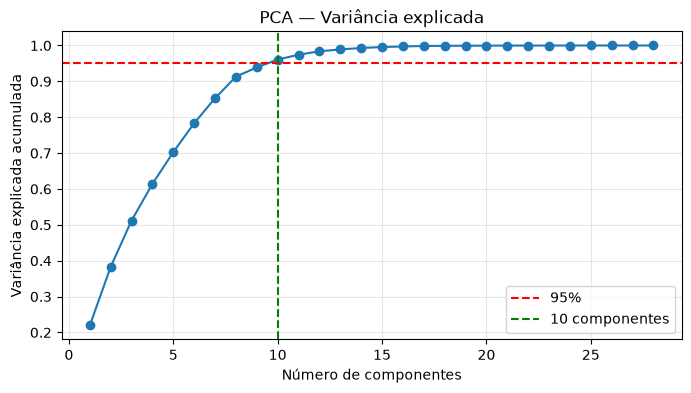

In [ ]:
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_prepared)
cumulative_variance = pca_full.explained_variance_ratio_.cumsum()
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f'Features antes do PCA: {X_prepared.shape[1]}')
print(f'Componentes para 95% da variância: {n_components_95}')
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.axhline(.95, color='red', linestyle='--', label='95%')
plt.axvline(n_components_95, color='green', linestyle='--', label=f'{n_components_95} componentes')
plt.xlabel('Número de componentes'); plt.ylabel('Variância explicada acumulada')
plt.title('PCA — Variância explicada'); plt.grid(alpha=.3); plt.legend(); plt.show()

In [ ]:
pca = PCA(n_components=n_components_95)
X_reduced = pca.fit_transform(X_prepared)
print(f'Formato após PCA: {X_reduced.shape}')
print(f'Variância explicada: {pca.explained_variance_ratio_.sum():.2%}')

Formato após PCA: (858, 10)
Variância explicada: 96.08%


## Classificadores

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier


classificadores = {
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(),
    'DT' : DecisionTreeClassifier(),
    'RF' : RandomForestClassifier(),
    'LR' : LogisticRegression(),
    'NB' : GaussianNB()
}

In [ ]:
import time
acuracia_treino = {}
tempo_treino    = {}

for clf in classificadores:
    start_time = time.process_time()
    classificadores[clf].fit(X_train, y_train)
    acuracia_treino[clf] = classificadores[clf].score(X_train, y_train)
    tempo_treino[clf]    = time.process_time() - start_time

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(x=list(acuracia_treino.keys()), y=list(acuracia_treino.values()), ax=ax[0], ec='k')
sns.barplot(x=list(acuracia_treino.keys()), y=list(acuracia_treino.values()), ax=ax[1], ec='k')

ax[0].set_yscale('log')
ax[0].set_title('Acurácia de Treino', size=15)

ax[1].set_yscale('log')
ax[1].set_title('Tempo Treinamento', size=15)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

metricas = {}

for clf in classificadores:
    metricas[clf] = {}
    classificadores[clf].fit(X_train, y_train)
    predictions   = classificadores[clf].predict(X_test)
    metricas[clf]['accuracy']  = accuracy_score(y_test, predictions)
    metricas[clf]['precision'] = precision_score(y_test, predictions)
    metricas[clf]['recall']    = recall_score(y_test, predictions)
    metricas[clf]['f1']        = f1_score(y_test, predictions)

resultado = pd.DataFrame(metricas)

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(15, 9))
ax      = ax.flatten()

for idx, clf in enumerate(classificadores):
    predictions = classificadores[clf].predict(X_test)
    cm = confusion_matrix(y_test, predictions, )
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=classificadores[clf].classes_, )
    disp.plot(ax=ax[idx], cmap='inferno') 
    ax[idx].set_title(clf)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

ks   = [3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 37, 33, 35, 53]
accs = []

for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    scores = cross_val_score(knn, x_treino, y_treino, cv=5)
    accs.append(scores.mean())

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(x=ks, y=accs, linewidth=3, ax=ax)
plt.grid(True, linestyle=':')
plt.xlabel('Número de vizinhos')
plt.ylabel('Acurácia média')